In [8]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from google.colab import drive
from sklearn.metrics import accuracy_score, f1_score

# Reproducibility
SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Mount Google Drive
drive.mount("/content/drive")

# Existing project structure
TASK_ROOT = Path("/content/drive/MyDrive/pa1-beyond-iid/task1")

DATA_PATH = TASK_ROOT / "data/stl10_labeled.npz"
FEATURE_DIR = TASK_ROOT / "results/features"
HEAD_DIR = TASK_ROOT / "models/heads"

# New Part C results folder
RESULT_DIR = TASK_ROOT / "results/clean_baseline"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ["resnet50", "vit_b16", "clip_b32"]

FEATURE_DIMS = {"resnet50": 2048, "vit_b16": 768, "clip_b32": 512}

#! Load evaluation labels and class information
with np.load(DATA_PATH, allow_pickle=False) as data:
    test_labels = data["test_labels"]
    test_indices = data["test_indices"]
    CLASS_NAMES = data["class_names"].tolist()

assert len(test_labels) == 500
assert len(np.unique(test_indices)) == 500

#! Verify all files needed for Part C
required_files = (
    [FEATURE_DIR / f"{name}_test.pt" for name in MODEL_NAMES]
    + [HEAD_DIR / f"{name}_head.pt" for name in MODEL_NAMES]
    + [FEATURE_DIR / "clip_zeroshot.pt"]
)
for path in required_files:
    assert path.is_file(), f"Missing file: {path}"
    print("Found:", path.name)

#! Verify feature dimensions, labels and image order
for name in MODEL_NAMES:
    saved = torch.load(FEATURE_DIR / f"{name}_test.pt", map_location="cpu", weights_only=True)

    assert saved["features"].shape == (500, FEATURE_DIMS[name])
    assert np.array_equal(saved["labels"].numpy(), test_labels)
    assert np.array_equal(saved["indices"].numpy(), test_indices)

print("\nAll checks passed!")
print("Device: CPU")
print("Evaluation images:", len(test_labels))
print("Results directory:", RESULT_DIR)

Mounted at /content/drive
Found: resnet50_test.pt
Found: vit_b16_test.pt
Found: clip_b32_test.pt
Found: resnet50_head.pt
Found: vit_b16_head.pt
Found: clip_b32_head.pt
Found: clip_zeroshot.pt

All checks passed!
Device: CPU
Evaluation images: 500
Results directory: /content/drive/MyDrive/pa1-beyond-iid/task1/results/clean_baseline


In [12]:
MODEL_ORDER = ["resnet50", "vit_b16", "clip_b32", "clip_zero_shot"]

EVAL_DIR = RESULT_DIR
SPLIT_PATH = TASK_ROOT / "data/split_indices.json"

class_counts = np.bincount(test_labels, minlength=10)

import sklearn

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support
)

In [9]:
logits_by_model = {}
features_by_model = {}
head_metadata = {}

for model_name in MODEL_NAMES:
    print(f"\nEvaluating: {model_name}")

    feature_data = torch.load(FEATURE_DIR / f"{model_name}_test.pt", map_location="cpu", weights_only=True)

    X_test = feature_data["features"].float()

    assert X_test.shape == (500, FEATURE_DIMS[model_name])

    checkpoint_path = (HEAD_DIR / f"{model_name}_head.pt")

    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)

    assert checkpoint["model_name"] == model_name
    assert checkpoint["seed"] == SEED

    assert checkpoint["in_features"] == X_test.shape[1]
    assert checkpoint["num_classes"] == 10

    head = nn.Linear(checkpoint["in_features"], checkpoint["num_classes"])
    head.load_state_dict(checkpoint["head_state_dict"])

    head.eval()

    with torch.inference_mode():
        logits = head(X_test)

    logits = logits.float().cpu()

    assert logits.shape == (500, 10)
    assert torch.isfinite(logits).all()

    logits_by_model[model_name] = logits

    features_by_model[model_name] = X_test

    head_metadata[model_name] = {
        "best_epoch": int(checkpoint["best_epoch"]),
        "best_val_accuracy": float(checkpoint["best_val_accuracy"]),
        "checkpoint_path": str(checkpoint_path)
    }

    print("Feature shape:", tuple(X_test.shape))
    print("Logits shape:", tuple(logits.shape))
    print("Best epoch:", checkpoint["best_epoch"])

    del head, checkpoint, feature_data

print("\nAll three linear classifiers evaluated.")


Evaluating: resnet50
Feature shape: (500, 2048)
Logits shape: (500, 10)
Best epoch: 10

Evaluating: vit_b16
Feature shape: (500, 768)
Logits shape: (500, 10)
Best epoch: 18

Evaluating: clip_b32
Feature shape: (500, 512)
Logits shape: (500, 10)
Best epoch: 6

All three linear classifiers evaluated.


In [10]:
zero_shot_data = torch.load(FEATURE_DIR / "clip_zeroshot.pt", map_location="cpu", weights_only=True)

text_features = zero_shot_data["text_features"].float()
image_features = features_by_model["clip_b32"]

logit_scale = float(zero_shot_data["logit_scale"])

expected_prompts = [f"a photo of a {name}." for name in CLASS_NAMES]

assert zero_shot_data["class_names"] == CLASS_NAMES
assert zero_shot_data["prompts"] == expected_prompts

assert image_features.shape == (500, 512)
assert text_features.shape == (10, 512)

assert torch.allclose(image_features.norm(dim=1), torch.ones(500), atol=1e-3)
assert torch.allclose(text_features.norm(dim=1), torch.ones(10), atol=1e-3)

assert np.isfinite(logit_scale)
assert logit_scale > 0

with torch.inference_mode():
    similarities = (image_features @ text_features.T)
    zero_shot_logits = (logit_scale * similarities)

assert zero_shot_logits.shape == (500, 10)
assert torch.isfinite(zero_shot_logits).all()

logits_by_model["clip_zero_shot"] = (zero_shot_logits.float())

print("Prompts:", expected_prompts)
print("Logit scale:", logit_scale)
print("Zero-shot logits:", tuple(zero_shot_logits.shape))
print("\nAll four models are ready for evaluation.")

Prompts: ['a photo of a airplane.', 'a photo of a bird.', 'a photo of a car.', 'a photo of a cat.', 'a photo of a deer.', 'a photo of a dog.', 'a photo of a horse.', 'a photo of a monkey.', 'a photo of a ship.', 'a photo of a truck.']
Logit scale: 100.0
Zero-shot logits: (500, 10)

All four models are ready for evaluation.


In [13]:
y_true = test_labels.copy()
image_ids = test_indices.copy()

predictions_table = pd.DataFrame({
    "image_id": image_ids,
    "true_label": y_true,
    "true_class": [CLASS_NAMES[i] for i in y_true]
})

summary_rows = []

for model_name in MODEL_ORDER:
    print(f"\nEvaluating: {model_name}")

    logits = logits_by_model[model_name]

    #! Convert raw logits to probabilities.
    with torch.inference_mode():
        probabilities = torch.softmax(logits,dim=1)
        confidence, predictions = probabilities.max(dim=1)

    #! Convert tensors to NumPy arrays.
    y_pred = predictions.cpu().numpy().astype(np.int64)
    conf = confidence.cpu().numpy()
    prob_np = probabilities.cpu().numpy()
    logits_np = logits.cpu().numpy()
    correct = (y_pred == y_true)

    #! Required metric 1: Accuracy

    accuracy = float(accuracy_score(y_true, y_pred))

    #! Required metric 2: Macro-F1

    macro_f1 = float(f1_score(y_true, y_pred, labels=list(range(10)), average="macro", zero_division=0))

    #! Required metric 3: Confidence
    mean_confidence = float(conf.mean())

    #! Sanity checks

    assert prob_np.shape == (500, 10)
    assert np.allclose(prob_np.sum(axis=1), 1.0, atol=1e-5)

    assert 0 <= accuracy <= 1
    assert 0 <= macro_f1 <= 1
    assert 0 <= mean_confidence <= 1

    #! Save complete predictions

    np.savez_compressed(
        EVAL_DIR / f"{model_name}_clean_predictions.npz",

        image_ids=image_ids,
        y_true=y_true,
        y_pred=y_pred,

        logits=logits_np,
        probabilities=prob_np,

        max_confidence=conf,
        correct=correct,

        class_names=np.asarray(CLASS_NAMES)
    )

    #!Confusion matrix

    cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

    cm_df.to_csv(EVAL_DIR / f"{model_name}_confusion.csv", index_label="true/predicted")

    #! Per-class metrics
    precision, recall, f1, support = (
        precision_recall_fscore_support(y_true, y_pred, labels=list(range(10)), zero_division=0)
    )

    per_class_df = pd.DataFrame({
        "class_name": CLASS_NAMES,
        "support": support,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    per_class_df.to_csv(EVAL_DIR / f"{model_name}_per_class.csv", index=False)

    #! Append per-image results

    predictions_table[f"{model_name}_pred_label"] = y_pred
    predictions_table[f"{model_name}_pred_class"] = [CLASS_NAMES[i] for i in y_pred]
    predictions_table[f"{model_name}_confidence"] = conf
    predictions_table[f"{model_name}_correct"] = correct

    #! Append aggregate results

    summary_rows.append({
        "model": model_name,
        "n_images": 500,
        "n_correct": int(correct.sum()),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "mean_max_confidence": mean_confidence,
        "seed": SEED
    })

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")
    print(f"Mean maximum confidence: {mean_confidence:.4f}")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(EVAL_DIR / "summary.csv", index=False)
predictions_table.to_csv(EVAL_DIR / "predictions.csv", index=False)

# Save JSON summary.
with open(EVAL_DIR / "summary.json", "w") as f:

    json.dump(
        {
            "seed": SEED,
            "n_images": 500,
            "class_names": CLASS_NAMES,
            "results": summary_rows
        },
        f,
        indent=2
    )


config = {
    "experiment": "Task 1 Part C - Clean Baseline",
    "seed": SEED,
    "dataset": "STL-10",
    "evaluation_images": 500,
    "images_per_class": class_counts.tolist(),
    "dataset_path": str(DATA_PATH),
    "split_path": str(SPLIT_PATH),
    "test_image_ids_path": str(EVAL_DIR / "clean_image_ids.npy"),
    "class_names": CLASS_NAMES,
    "models": MODEL_ORDER,
    "feature_dimensions": FEATURE_DIMS,
    "classifier_checkpoints": head_metadata,
    "zero_shot": {
                  "prompts": expected_prompts,
                  "logit_scale": logit_scale,
                  "text_embedding_path": str(FEATURE_DIR / "clip_zeroshot.pt")
                  },
    "preprocessing": {
                  "common_image": "224x224 RGB, bicubic resize",
                  "resnet_vit_normalization": "ImageNet mean/std",
                  "clip_normalization": "OpenCLIP mean/std"
                     },

    "metrics": ["top_1_accuracy", "macro_f1", "mean_max_confidence"],

    "versions": {
                  "torch": torch.__version__,
                  "sklearn": sklearn.__version__,
                  "numpy": np.__version__
                }
}

with open(EVAL_DIR / "evaluation_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("\n========== CLEAN BASELINE ==========")
display(summary_df.round(4))

print("\nAll numerical results saved to:")
print(EVAL_DIR)


Evaluating: resnet50
Accuracy: 0.9760
Macro-F1: 0.9761
Mean maximum confidence: 0.9349

Evaluating: vit_b16
Accuracy: 0.9740
Macro-F1: 0.9739
Mean maximum confidence: 0.9684

Evaluating: clip_b32
Accuracy: 0.9800
Macro-F1: 0.9800
Mean maximum confidence: 0.2415

Evaluating: clip_zero_shot
Accuracy: 0.9680
Macro-F1: 0.9675
Mean maximum confidence: 0.9427

========== CLEAN BASELINE ==========


,model,n_images,n_correct,accuracy,macro_f1,mean_max_confidence,seed
0,resnet50,500,488,0.976,0.9761,0.9349,6304
1,vit_b16,500,487,0.974,0.9739,0.9684,6304
2,clip_b32,500,490,0.980,0.9800,0.2415,6304
3,clip_zero_shot,500,484,0.968,0.9675,0.9427,6304



All numerical results saved to:
/content/drive/MyDrive/pa1-beyond-iid/task1/results/clean_baseline


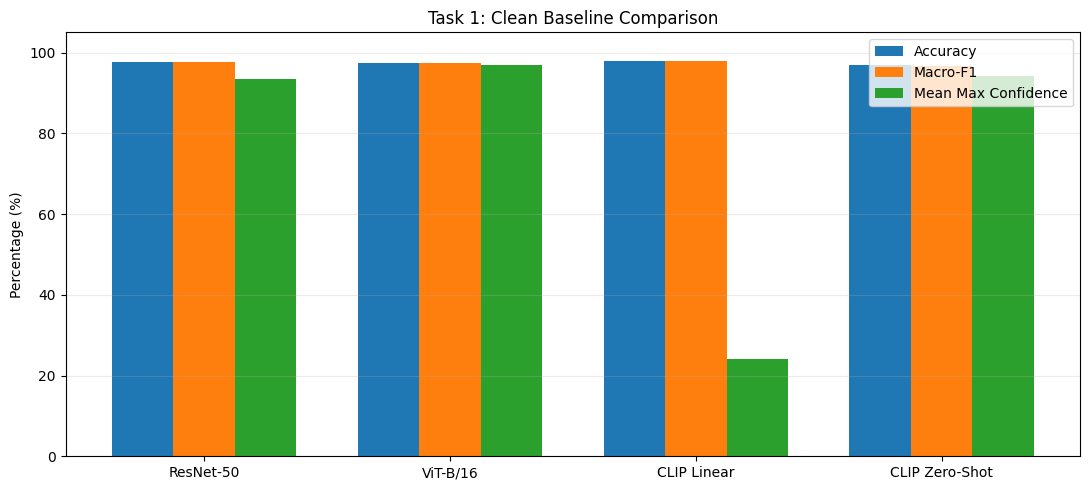

Figure saved: /content/drive/MyDrive/pa1-beyond-iid/task1/results/clean_baseline/clean_baseline_comparison.png


In [14]:
import matplotlib.pyplot as plt

model_labels = ["ResNet-50", "ViT-B/16", "CLIP Linear", "CLIP Zero-Shot"]
x = np.arange(len(model_labels))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
        x - width,
        summary_df["accuracy"].to_numpy() * 100,
        width,
        label="Accuracy"
      )

ax.bar(
        x,
        summary_df["macro_f1"].to_numpy() * 100,
        width,
        label="Macro-F1"
      )

ax.bar(
        x + width,
        summary_df["mean_max_confidence"].to_numpy() * 100,
        width,
        label="Mean Max Confidence"
      )

ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylabel("Percentage (%)")
ax.set_title("Task 1: Clean Baseline Comparison")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

figure_path = (EVAL_DIR / "clean_baseline_comparison.png")
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved:", figure_path)

In [17]:
# Cell 6 — Final verification

summary = pd.read_csv(EVAL_DIR / "summary.csv")
predictions = pd.read_csv(EVAL_DIR / "predictions.csv")

np.save(EVAL_DIR / "clean_image_ids.npy", test_indices)

required_files = [
    "summary.csv",
    "summary.json",
    "predictions.csv",
    "evaluation_config.json",
    "clean_image_ids.npy",
    "clean_baseline_comparison.png",
]

for model in MODEL_ORDER:
    required_files.extend([
              f"{model}_clean_predictions.npz",
              f"{model}_confusion.csv",
              f"{model}_per_class.csv"
    ])

missing = [name for name in required_files if not (EVAL_DIR / name).is_file()]

if missing:
    raise FileNotFoundError(f"Missing files: {missing}")

for model in MODEL_ORDER:
    with np.load(EVAL_DIR / f"{model}_clean_predictions.npz") as data:
        print(f"{model}: " f"{len(data['y_pred'])} predictions saved")

print("\nPART C COMPLETE")
print("Evaluation images:", len(predictions))
print("Files verified:", len(required_files))
print("Results saved to:", EVAL_DIR)

display(summary.round(4))

resnet50: 500 predictions saved
vit_b16: 500 predictions saved
clip_b32: 500 predictions saved
clip_zero_shot: 500 predictions saved

PART C COMPLETE
Evaluation images: 500
Files verified: 18
Results saved to: /content/drive/MyDrive/pa1-beyond-iid/task1/results/clean_baseline


,model,n_images,n_correct,accuracy,macro_f1,mean_max_confidence,seed
0,resnet50,500,488,0.976,0.9761,0.9349,6304
1,vit_b16,500,487,0.974,0.9739,0.9684,6304
2,clip_b32,500,490,0.980,0.9800,0.2415,6304
3,clip_zero_shot,500,484,0.968,0.9675,0.9427,6304
